# Import Packages

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import itertools
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import chi2_contingency

# Load Data

In [3]:
df = pd.read_csv('/content/flight.csv')
df.head()

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME,...,SUM_YR_2,SEG_KM_SUM,LAST_FLIGHT_DATE,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight
0,54993,11/2/2006,12/24/2008,Male,6,.,beijing,CN,31.0,3/31/2014,...,234188.0,580717,3/31/2014,1,3.483254,18,34,0.961639,619760,50
1,28065,2/19/2007,8/3/2007,Male,6,NaN,beijing,CN,42.0,3/31/2014,...,167434.0,293678,3/25/2014,7,5.194245,17,29,1.252314,415768,33
2,55106,2/1/2007,8/30/2007,Male,6,.,beijing,CN,40.0,3/31/2014,...,164982.0,283712,3/21/2014,11,5.298507,18,20,1.254676,406361,26
3,21189,8/22/2008,8/23/2008,Male,5,Los Angeles,CA,US,64.0,3/31/2014,...,125500.0,281336,12/26/2013,97,27.863636,73,11,1.090870,372204,12
4,39546,4/10/2009,4/15/2009,Male,6,guiyang,guizhou,CN,48.0,3/31/2014,...,130702.0,309928,3/27/2014,5,4.788079,47,27,0.970658,338813,39


# Basic Analysis

## Numeric Analysis

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62988 entries, 0 to 62987
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MEMBER_NO          62988 non-null  int64  
 1   FFP_DATE           62988 non-null  object 
 2   FIRST_FLIGHT_DATE  62988 non-null  object 
 3   GENDER             62985 non-null  object 
 4   FFP_TIER           62988 non-null  int64  
 5   WORK_CITY          60719 non-null  object 
 6   WORK_PROVINCE      59740 non-null  object 
 7   WORK_COUNTRY       62962 non-null  object 
 8   AGE                62568 non-null  float64
 9   LOAD_TIME          62988 non-null  object 
 10  FLIGHT_COUNT       62988 non-null  int64  
 11  BP_SUM             62988 non-null  int64  
 12  SUM_YR_1           62437 non-null  float64
 13  SUM_YR_2           62850 non-null  float64
 14  SEG_KM_SUM         62988 non-null  int64  
 15  LAST_FLIGHT_DATE   62988 non-null  object 
 16  LAST_TO_END        629

In [ ]:
df.describe()

,MEMBER_NO,FFP_TIER,AGE,FLIGHT_COUNT,BP_SUM,SUM_YR_1,SUM_YR_2,SEG_KM_SUM,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight
count,62988.000000,62988.000000,62568.000000,62988.000000,62988.000000,62437.000000,62850.000000,62988.000000,62988.000000,62988.000000,62988.000000,62988.000000,62988.000000,62988.0000,62988.000000
mean,31494.500000,4.102162,42.476346,11.839414,10925.081254,5355.376064,5604.026014,17123.878691,176.120102,67.749788,166.033895,0.319775,0.721558,12545.7771,2.728155
std,18183.213715,0.373856,9.885915,14.049471,16339.486151,8109.450147,8703.364247,20960.844623,183.822223,77.517866,123.397180,1.136004,0.185427,20507.8167,7.364164
min,1.000000,4.000000,6.000000,2.000000,0.000000,0.000000,0.000000,368.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000
25%,15747.750000,4.000000,35.000000,3.000000,2518.000000,1003.000000,780.000000,4747.000000,29.000000,23.370370,79.000000,0.000000,0.611997,2775.0000,0.000000
50%,31494.500000,4.000000,41.000000,7.000000,5700.000000,2800.000000,2773.000000,9994.000000,108.000000,44.666667,143.000000,0.000000,0.711856,6328.5000,0.000000
75%,47241.250000,4.000000,48.000000,15.000000,12831.000000,6574.000000,6845.750000,21271.250000,268.000000,82.000000,228.000000,0.000000,0.809476,14302.5000,1.000000
max,62988.000000,6.000000,110.000000,213.000000,505308.000000,239560.000000,234188.000000,580717.000000,731.000000,728.000000,728.000000,46.000000,1.500000,985572.0000,140.000000


In [ ]:
df[['GENDER', 'WORK_CITY', 'WORK_PROVINCE', 'WORK_COUNTRY', 'LOAD_TIME']].describe()

,GENDER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,LOAD_TIME
count,62985,60719,59740,62962,62988
unique,2,3234,1165,118,1
top,Male,guangzhou,guangdong,CN,3/31/2014
freq,48134,9386,17509,57748,62988


## Garbage Data Detection

### 'MEMBER_NO' Value Check

In [ ]:
df['MEMBER_NO'].isna().sum()

np.int64(0)

In [ ]:
df[df['MEMBER_NO'].duplicated()]

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME,...,SUM_YR_2,SEG_KM_SUM,LAST_FLIGHT_DATE,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight


### 'FFP_DATE' Value Check

#### 'FFP_DATE' Data Type Reassignment

In [ ]:
df['FFP_DATE'] = pd.to_datetime(
    df['FFP_DATE'],
    format='%m/%d/%Y',
    errors='coerce'
)

#### 'FFP_DATE' Invalid Value Checker

In [ ]:
df['FFP_DATE'].isna().sum()

np.int64(0)

### 'FIRST_FLIGHT_DATE' Value Check

#### 'FIRST_FLIGHT_DATE' Data Type Reassignment

In [ ]:
df['FIRST_FLIGHT_DATE'] = pd.to_datetime(
    df['FIRST_FLIGHT_DATE'],
    format='%m/%d/%Y',
    errors='coerce'
)

#### 'FIRST_FLIGHT_DATE' Invalid Value Checker

In [ ]:
df['FIRST_FLIGHT_DATE'].isna().sum()

np.int64(0)

### 'GENDER' Value Check

In [ ]:
mask = ~df['GENDER'].isin(['Female', 'Male'])
df.loc[mask]

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME,...,SUM_YR_2,SEG_KM_SUM,LAST_FLIGHT_DATE,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight
271,58411,2009-12-12,2010-04-15,NaN,6,MENAI,SYDNEY,AU,61.0,3/31/2014,...,89477.0,105377,3/31/2014,1,43.000000,175,2,1.056396,159060,3
22471,55908,2012-10-14,2013-01-14,NaN,4,PARAMUS,NEW JERSEY,US,43.0,3/31/2014,...,5670.0,8604,3/18/2014,14,61.285714,173,0,1.258319,12220,0
42565,4533,2011-01-25,2011-02-01,NaN,4,guangzhoushi,guangdong,CN,62.0,3/31/2014,...,0.0,7845,2/26/2013,400,16.250000,31,0,0.521791,2982,0


### 'FFP_TIER' Value Check

In [ ]:
df['FFP_TIER'].isna().sum()

np.int64(0)

### 'WORK_CITY' Value Check

In [ ]:
df['WORK_CITY'].isna().sum()

np.int64(2269)

In [ ]:
# Check if WORK_CITY only consists of either number or special characters
mask = df['WORK_CITY'].str.match(r'^[^A-Za-z\s]+$', na=False)

# mask = df['WORK_CITY'].str.match(
#     r'^(?:\s*$|.*\d.*|.*[^A-Za-z0-9\s].*)',
#     na=True
# )

len(df.loc[mask, 'WORK_CITY'])

787

### 'WORK_PROVINCE' Value Check

In [ ]:
df['WORK_PROVINCE'].isna().sum()

np.int64(3248)

In [ ]:
# Check if WORK_CITY only consists of either number or special characters
mask = df['WORK_PROVINCE'].str.match(r'^[^A-Za-z\s]+$', na=False)

# mask = df['WORK_CITY'].str.match(
#     r'^(?:\s*$|.*\d.*|.*[^A-Za-z0-9\s].*)',
#     na=True
# )

len(df.loc[mask, 'WORK_PROVINCE'])

1283

### 'WORK_COUNTRY' Value Check

In [ ]:
df['WORK_COUNTRY'].isna().sum()

np.int64(26)

### 'AGE' Value Check

In [ ]:
df['AGE'].isna().sum()

np.int64(420)

### 'LOAD_TIME' Value Check

In [ ]:
df['LOAD_TIME'].unique()

array(['3/31/2014'], dtype=object)

### 'FLIGHT_COUNT' Value Check

In [ ]:
df['FLIGHT_COUNT'].isna().sum()

np.int64(0)

### 'BP_SUM' Value Check

In [ ]:
df['BP_SUM'].isna().sum()

np.int64(0)

### 'SUM_YR_1' Value Check

In [ ]:
df['SUM_YR_1'].isna().sum()

np.int64(551)

### 'SUM_YR_2' Value Check

In [ ]:
df['SUM_YR_2'].isna().sum()

np.int64(138)

### 'SEG_KM_SUM' Value Check

In [ ]:
df['SEG_KM_SUM'].isna().sum()

np.int64(0)

### 'LAST_FLIGHT_DATE' Value Check

#### 'LAST_FLIGHT_DATE' Data Type Reassignment

In [ ]:
df['LAST_FLIGHT_DATE'] = pd.to_datetime(
    df['LAST_FLIGHT_DATE'],
    format='%m/%d/%Y',
    errors='coerce'
)

#### 'LAST_FLIGHT_DATE' Invalid Value Checker

In [ ]:
df['LAST_FLIGHT_DATE'].isna().sum()

np.int64(0)

### 'LAST_TO_END' Value Check

In [ ]:
df['LAST_TO_END'].isna().sum()

np.int64(0)

### 'AVG_INTERVAL' Value Check

In [ ]:
df['AVG_INTERVAL'].isna().sum()

np.int64(0)

### 'MAX_INTERVAL' Value Check

In [ ]:
df['MAX_INTERVAL'].isna().sum()

np.int64(0)

### 'EXCHANGE_COUNT' Value Check

In [ ]:
df['EXCHANGE_COUNT'].isna().sum()

np.int64(0)

### 'avg_discount' Value Check

In [ ]:
df['avg_discount'].isna().sum()

np.int64(0)

### 'Points_Sum' Value Check

In [ ]:
df['Points_Sum'].isna().sum()

np.int64(0)

### 'Point_NotFlight' Value Check

In [ ]:
df['Point_NotFlight'].isna().sum()

np.int64(0)

### Conclusion

#### Method

*   Data Numerikal:
    *   Dikarenakan pandas sudah secara otomatis melakukan konversi data yang bersifat <i>object</i> namun berada di kolom int/float menjadi 'NaN', maka hanya perlu pengecekan nilai null di dalam kolom-kolom numerikal tersebut  
*   Data Non-Numerikal:
    *   Dikarenakan banyak nya variasi di kolom ini, maka perlakuannya akan berbeda per kolom.
*   Data Temporal/Tanggal:
    *   Kolom di konversi ke tipe data tanggal, dengan begitu jika ada nilai yang tidak sesuai, maka secara otomatis data yang tidak sesuai akan berubah menjadi nilai 'NaT' yang bisa di cek dengan fungsi isna().



#### Result (Concise)

*   FIRST_FLIGHT_DATE:
    *   Dari pengecekan, ditemukan 3 baris yang memiliki nilai yang jauh diluar rata-rata
*   GENDER:
    *   Kolom ditemukan memiliki 3 baris dimana nilai nya bukan 'Female' maupun 'Male'.
*   WORK_CITY:
    *   Dikarenakan sifat nilai di kolom ini yang sangat bervariasi (dengan total 3234 nilai yang DISTINCT), maka tidak mungkin dilakukan pengecekan apakah semua nilai di kolom ini benar-benar memang nama dari sebuah kota.<br>Dengan begitu ditentukan bahwa dilakukan pengecekan jika nilai di kolom hanya ada angka ataupun karakter spesial ataupun kosong sama sekali, maka dianggap tidak benar.<br>Dari pengecekan ditemukan ada 787 baris yang memiliki nilai kolom 'WORK_CITY' yang tidak benar & 2269 baris yang memiliki nilai null.
*   WORK_PROVINCE:
    *   Dikarenakan sifat nilai di kolom ini yang sangat bervariasi (dengan total 1165 nilai yang DISTINCT), maka tidak mungkin dilakukan pengecekan apakah semua nilai di kolom ini benar-benar memang nama dari sebuah provinsi.<br>Dengan begitu ditentukan bahwa dilakukan pengecekan jika nilai di kolom hanya ada angka ataupun karakter spesial ataupun kosong sama sekali, maka dianggap tidak benar.<br>Dari pengecekan ditemukan ada 1283 baris yang memiliki nilai kolom 'WORK_PROVINCE' yang tidak benar & 3248 baris yang memiliki nilai null.
*   WORK_COUNTRY:
    *   Dikarenakan nilai-nilai di kolom ini memiliki karakteristik akan sama dengan 2 karakter, ataupun berkarakter mandarin. Maka hanya akan dilakukan pengecekan untuk nilai null saja.<br>Dari pengecekan ditemukan ada 26 baris yang memiliki nilai null.
*   AGE:
    *   Dikarenakan kolom ini sudah termasuk tipe data numerik, maka sudah akan terjamin bahwa tidak akan ada nilai berupa string, maka akan dilakukan pengecekan nilai NaN ataupun null.<br>Dari hasil pengecekan ditemukan bahwa ada 420 baris yang memiliki nilai 'AGE' null/tidak benar.
*   LOAD_TIME:
    *   Ditemukan bahwa kolom ini memiliki nilai yang sama untuk semua baris. Maka ditentukan bahwa kolom ini akan dihapus dari dataset, dikarenakan memiliki variasi yang terlalu sedikit dan tidak akan bisa dipakai untuk segmentasi.
*   SUM_YR_1:
    *   Ditemukan bahwa kolom ini mempunyai 551 baris dengan nilai null.
*   SUM_YR_2:
    *   Ditemukan bahwa kolom ini mempunyai 138 baris dengan nilai null.
*   LAST_FLIGHT_DATE:
    *   Ditemukan bahwa kolom ini memiliki 421 baris dimana nilai kolom ini *invalid* atau null.

#### Result (Detailed)

*   MEMBER_NO:
    *   Tidak ditemukannya data duplikat di kolom ini.
*   FFP_DATE:
    *   Dari pengecekan, tidak ditemukan baris yang memiliki nilai 'FFP_DATE' yang *invalid*.
*   FIRST_FLIGHT_DATE:
    *   Dari pengecekan, ditemukan 3 baris yang memiliki nilai yang jauh diluar rata-rata.
*   GENDER:
    *   Kolom ditemukan memiliki 3 baris dimana nilai nya bukan 'Female' maupun 'Male'.
*   FFP_TIER:
    *   Tidak ditemukannya data null di kolom ini.
*   WORK_CITY:
    *   Dikarenakan sifat nilai di kolom ini yang sangat bervariasi (dengan total 3234 nilai yang DISTINCT), maka tidak mungkin dilakukan pengecekan apakah semua nilai di kolom ini benar-benar memang nama dari sebuah kota.<br>Dengan begitu ditentukan bahwa dilakukan pengecekan jika nilai di kolom hanya ada angka ataupun karakter spesial ataupun kosong sama sekali, maka dianggap tidak benar.<br>Dari pengecekan ditemukan ada 787 baris yang memiliki nilai kolom 'WORK_CITY' yang tidak benar & 2269 baris yang memiliki nilai null.
*   WORK_PROVINCE:
    *   Dikarenakan sifat nilai di kolom ini yang sangat bervariasi (dengan total 1165 nilai yang DISTINCT), maka tidak mungkin dilakukan pengecekan apakah semua nilai di kolom ini benar-benar memang nama dari sebuah provinsi.<br>Dengan begitu ditentukan bahwa dilakukan pengecekan jika nilai di kolom hanya ada angka ataupun karakter spesial ataupun kosong sama sekali, maka dianggap tidak benar.<br>Dari pengecekan ditemukan ada 1283 baris yang memiliki nilai kolom 'WORK_PROVINCE' yang tidak benar & 3248 baris yang memiliki nilai null.
*   WORK_COUNTRY:
    *   Dikarenakan nilai-nilai di kolom ini memiliki karakteristik akan sama dengan 2 karakter, ataupun berkarakter mandarin. Maka hanya akan dilakukan pengecekan untuk nilai null saja.<br>Dari pengecekan ditemukan ada 26 baris yang memiliki nilai null.
*   AGE:
    *   Dikarenakan kolom ini sudah termasuk tipe data numerik, maka sudah akan terjamin bahwa tidak akan ada nilai berupa string, maka akan dilakukan pengecekan nilai NaN ataupun null.<br>Dari hasil pengecekan ditemukan bahwa ada 420 baris yang memiliki nilai 'AGE' null/tidak benar.
*   LOAD_TIME:
    *   Ditemukan bahwa kolom ini memiliki nilai yang sama untuk semua baris. Maka ditentukan bahwa kolom ini akan dihapus dari dataset, dikarenakan memiliki variasi yang terlalu sedikit dan tidak akan bisa dipakai untuk segmentasi.
*   FLIGHT_COUNT:
    *   Ditemukan bahwa kolom ini tidak mempunyai nilai null.
*   BP_SUM:
    *   Ditemukan bahwa kolom ini tidak mempunyai nilai null.
*   SUM_YR_1:
    *   Ditemukan bahwa kolom ini mempunyai 551 baris dengan nilai null.
*   SUM_YR_2:
    *   Ditemukan bahwa kolom ini mempunyai 138 baris dengan nilai null.
*   SEG_KM_SUM:
    *   Ditemukan bahwa kolom ini tidak mempunyai nilai null.
*   LAST_FLIGHT_DATE:
    *   Ditemukan bahwa kolom ini memiliki 421 baris dimana nilai kolom ini *invalid* atau null.
*   LAST_TO_END:
    *   Ditemukan bahwa kolom ini tidak mempunyai nilai null.
*   AVG_INTERVAL:
    *   Ditemukan bahwa kolom ini tidak mempunyai nilai null.
*   MAX_INTERVAL:
    *   Ditemukan bahwa kolom ini tidak mempunyai nilai null.
*   EXCHANGE_COUNT:
    *   Ditemukan bahwa kolom ini tidak mempunyai nilai null.
*   avg_discount:
    *   Ditemukan bahwa kolom ini tidak mempunyai nilai null.
*   Points_Sum:
    *   Ditemukan bahwa kolom ini tidak mempunyai nilai null.
*   Point_NotFlight:
    *   Ditemukan bahwa kolom ini tidak mempunyai nilai null.

# Data Pre-Processing

## Reformat Temporal Data

In [26]:
df['FFP_DATE'] = pd.to_datetime(df['FFP_DATE'], format='%m/%d/%Y', errors='coerce')
df['FIRST_FLIGHT_DATE'] = pd.to_datetime(df['FIRST_FLIGHT_DATE'], format='%m/%d/%Y', errors='coerce')
df['LAST_FLIGHT_DATE'] = pd.to_datetime(df['LAST_FLIGHT_DATE'], format='%m/%d/%Y', errors='coerce')

## Label Encoding

In [27]:
df["GENDER"] = df["GENDER"].map({"Male": 0, "Female": 1})

## Deleting Garbage Data

In [28]:
df = df[df['FIRST_FLIGHT_DATE'].dt.year != 1905]

# Exploratory Data Analysis

## Univariate Analysis

In [ ]:
# Calculate percentage of a category for pie graph
def autopct_with_counts(values):
    def _autopct(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n ({count})"
    return _autopct

### 'FFP_DATE' Analysis

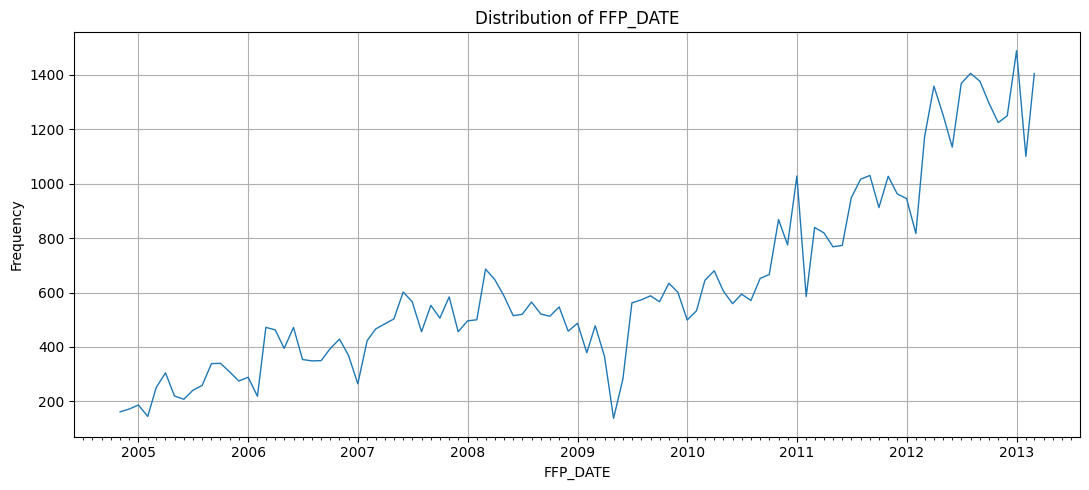

In [ ]:
# group by year-month
monthly_counts = (
    df.dropna(subset=['FFP_DATE'])
      .groupby(df['FFP_DATE'].dt.to_period('M'))
      .size()
)

# convert PeriodIndex to Timestamp
monthly_counts.index = monthly_counts.index.to_timestamp()

# plot
plt.figure(figsize=(11, 5))
plt.plot(monthly_counts.index, monthly_counts.values, linewidth=1.0)

ax = plt.gca()

# show x-axis labels once per year
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# optional: minor ticks for months (no labels)
ax.xaxis.set_minor_locator(mdates.MonthLocator())

plt.xlabel('FFP_DATE')
plt.ylabel('Frequency')
plt.title('Distribution of FFP_DATE')
plt.grid(True)
plt.tight_layout()
plt.show()

### 'FIRST_FLIGHT_DATE' Analysis

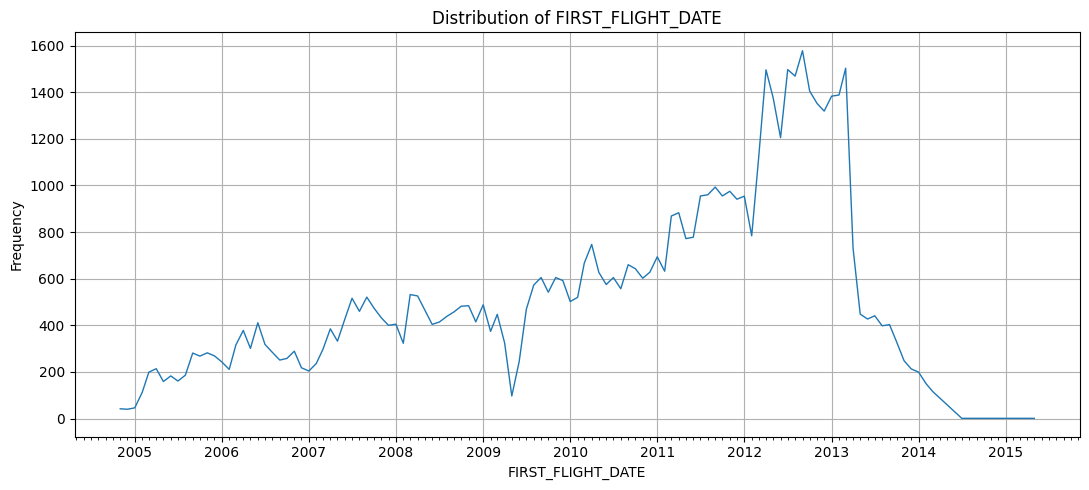

In [ ]:
monthly_counts = (
    df.dropna(subset=['FIRST_FLIGHT_DATE'])
      .groupby(df['FIRST_FLIGHT_DATE'].dt.to_period('M'))
      .size()
)

# convert PeriodIndex to Timestamp
monthly_counts.index = monthly_counts.index.to_timestamp()

# plot
plt.figure(figsize=(11, 5))
plt.plot(monthly_counts.index, monthly_counts.values, linewidth=1.0)

ax = plt.gca()

# show x-axis labels once per year
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# optional: minor ticks for months (no labels)
ax.xaxis.set_minor_locator(mdates.MonthLocator())

plt.xlabel('FIRST_FLIGHT_DATE')
plt.ylabel('Frequency')
plt.title('Distribution of FIRST_FLIGHT_DATE')
plt.grid(True)
plt.tight_layout()
plt.show()

### 'GENDER' Analysis

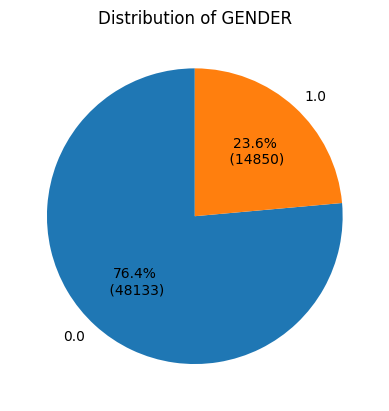

In [ ]:
label_map = {
    1: "Female",
    0: "Male"
}

counts = df["GENDER"].value_counts()
labels = counts.index.map(lambda x: label_map.get(x, x))


plt.pie(
    counts,
    labels=counts.index,
    autopct=autopct_with_counts(counts),
    startangle=90
)
plt.title("Distribution of GENDER")
plt.show()

### 'FFP_TIER' Analysis

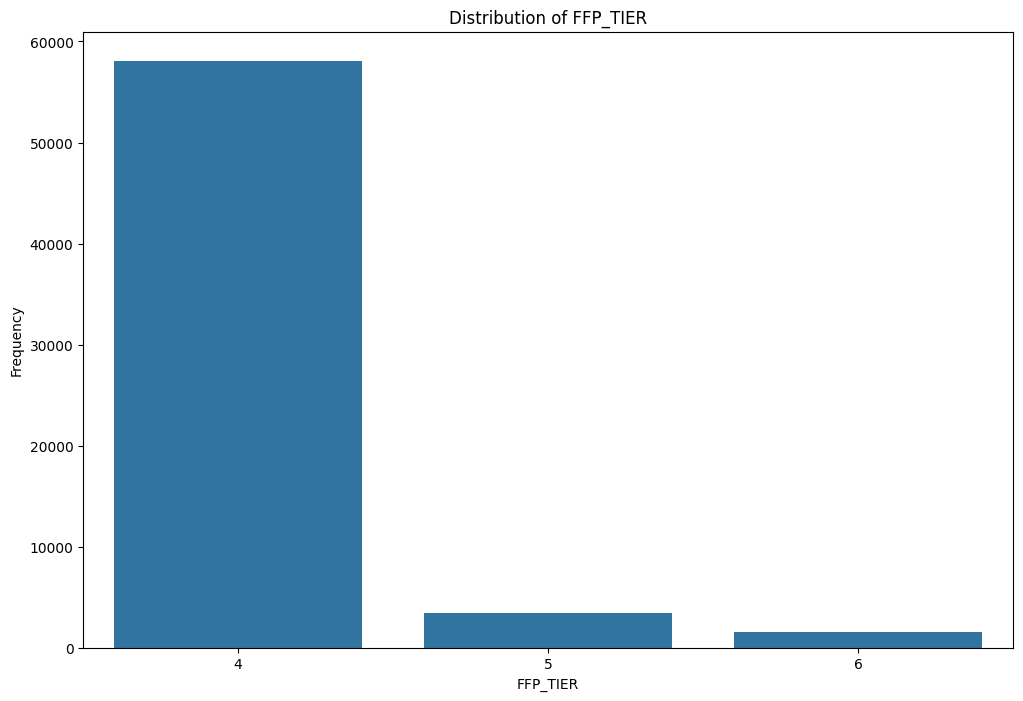

In [ ]:
plt.figure(figsize=(12, 8))
plt.title('Distribution of FFP_TIER')
plt.ylabel('Frequency')
sns.countplot(data=df, x="FFP_TIER")
plt.show()

### 'WORK_CITY' Analysis

/tmp/ipython-input-2641566418.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='left')


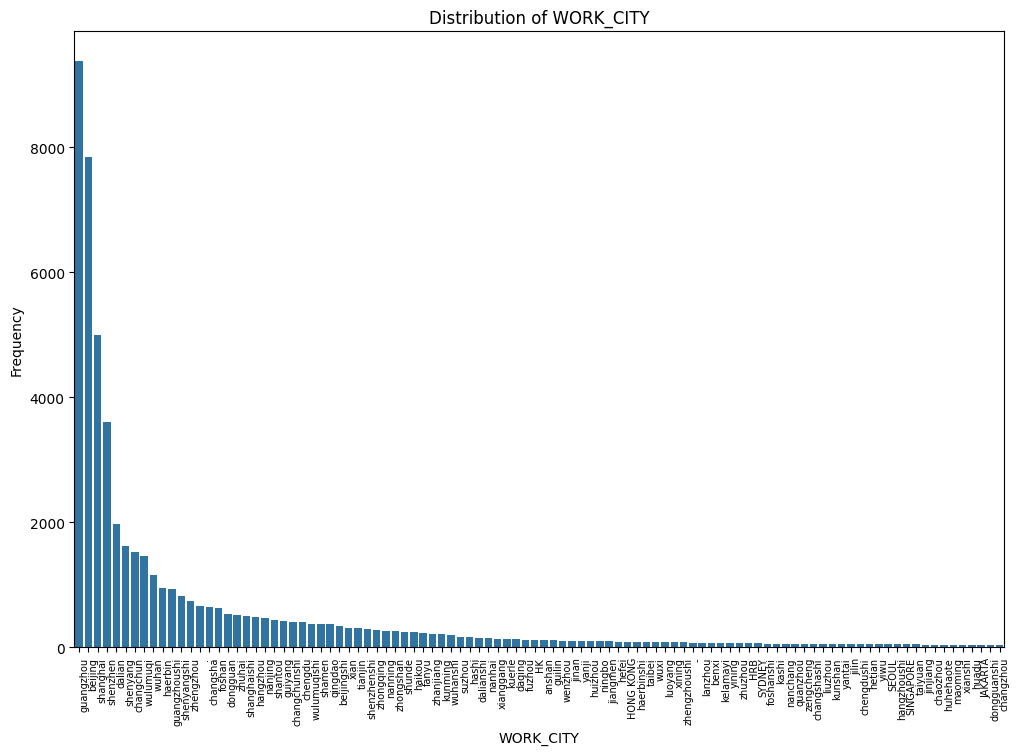

In [ ]:
top100_title = df["WORK_CITY"].value_counts().head(100)
order_title = top100_title.index.tolist()

# print(top100_title)

plt.figure(figsize=(12, 8))
ax = sns.countplot(data=df[df["WORK_CITY"].isin(order_title)], x="WORK_CITY", order=order_title)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='left')
ax.tick_params(axis='x', labelsize=7)
plt.title('Distribution of WORK_CITY')
plt.ylabel('Frequency')
plt.show()

### 'WORK_PROVINCE' Analysis

/tmp/ipython-input-3615251733.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='left')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12288 (\N{IDEOGRAPHIC SPACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


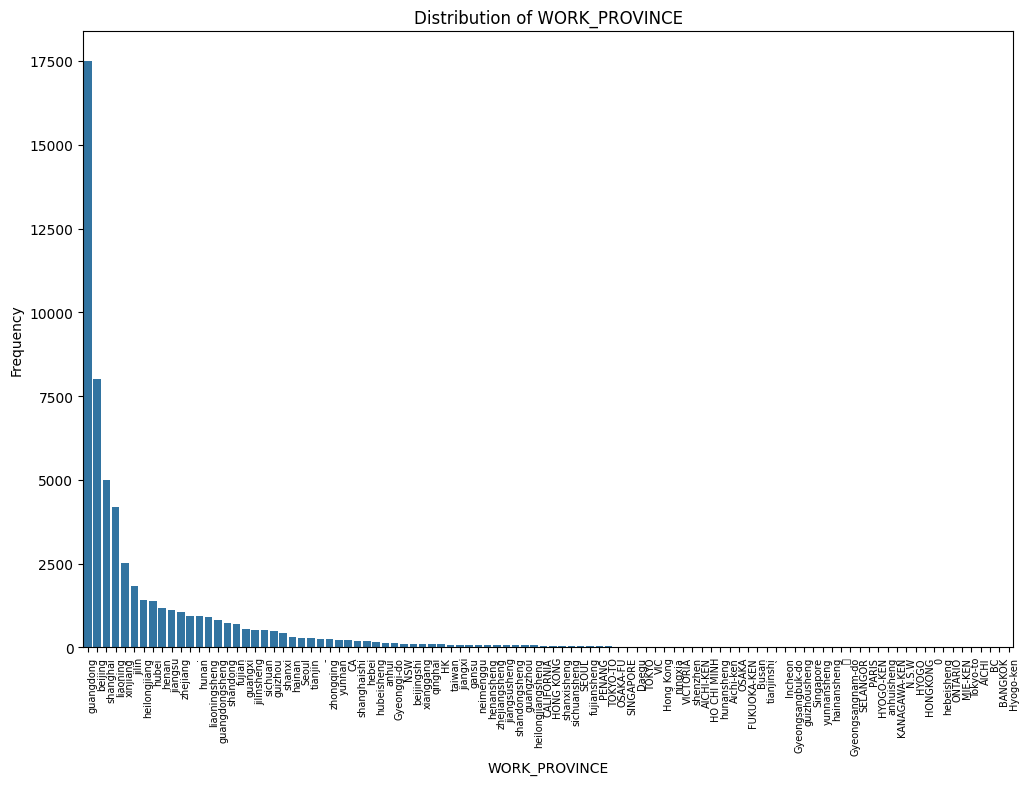

In [ ]:
top100_title = df["WORK_PROVINCE"].value_counts().head(100)
order_title = top100_title.index.tolist()

# print(top100_title)

plt.figure(figsize=(12, 8))
plt.title('Distribution of WORK_PROVINCE')
ax = sns.countplot(data=df[df["WORK_PROVINCE"].isin(order_title)], x="WORK_PROVINCE", order=order_title)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='left')
ax.tick_params(axis='x', labelsize=7)
plt.ylabel('Frequency')
plt.show()

### 'WORK_COUNTRY' Analysis

/tmp/ipython-input-748850594.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='left')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21271 (\N{CJK UNIFIED IDEOGRAPH-5317}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


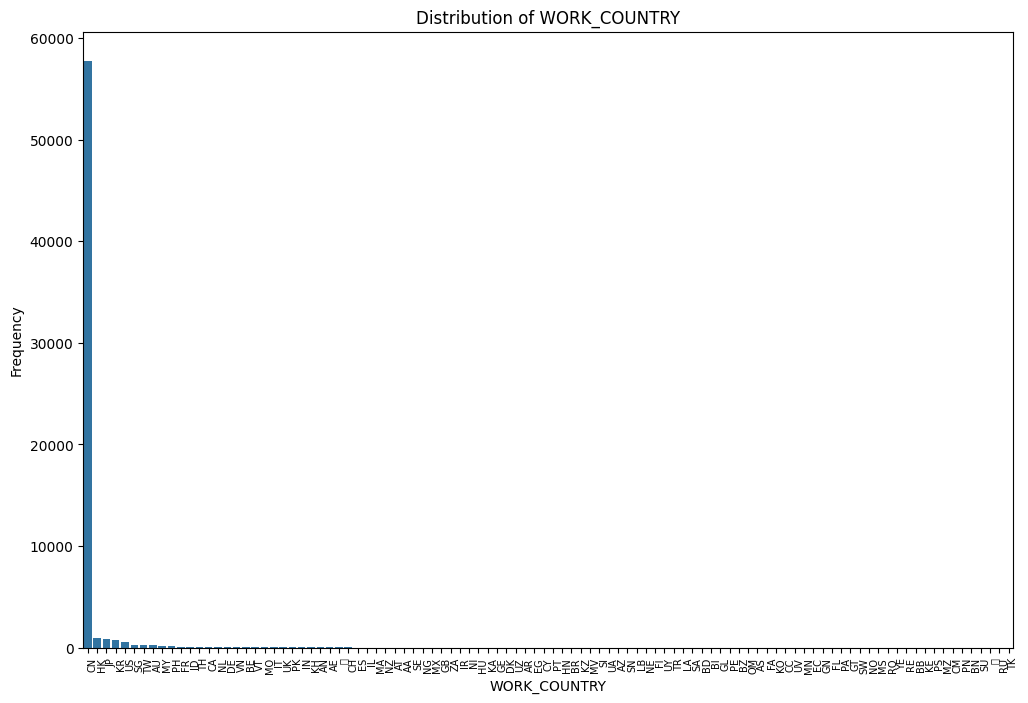

In [ ]:
top100_title = df["WORK_COUNTRY"].value_counts().head(100)
order_title = top100_title.index.tolist()

# print(top100_title)

plt.figure(figsize=(12, 8))
plt.title('Distribution of WORK_COUNTRY')
ax = sns.countplot(data=df[df["WORK_COUNTRY"].isin(order_title)], x="WORK_COUNTRY", order=order_title)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='left')
ax.tick_params(axis='x', labelsize=7)
plt.ylabel('Frequency')
plt.show()

### 'AGE' Analysis

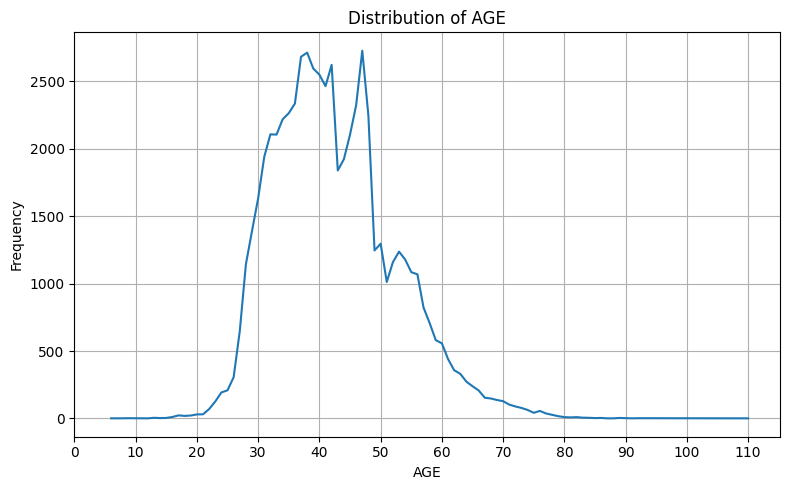

In [ ]:
age_counts = (
    df['AGE']
    .value_counts()
    .sort_index()
)
xmin = int(age_counts.index.min())
xmax = int(age_counts.index.max())

plt.figure(figsize=(8, 5))
plt.plot(age_counts.index, age_counts.values)

plt.xticks(range(xmin - xmin % 10, xmax + 10, 10))
plt.xlabel('AGE')
plt.ylabel('Frequency')
plt.title('Distribution of AGE')
plt.grid(True)
plt.tight_layout()
plt.show()

### 'LOAD_TIME' Analysis

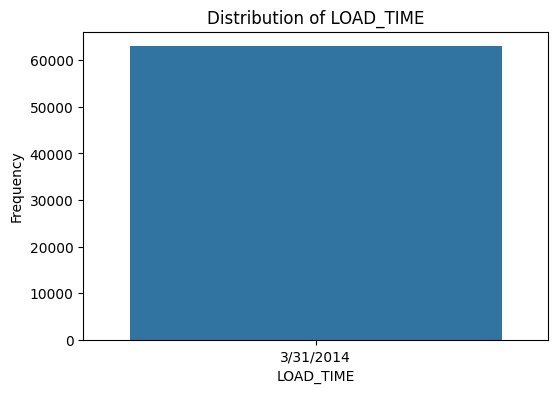

In [ ]:
plt.figure(figsize=(6, 4))
plt.title('Distribution of LOAD_TIME')
plt.ylabel('Frequency')
sns.countplot(data=df, x="LOAD_TIME")
plt.show()

### 'FLIGHT_COUNT' Analysis

In [ ]:
age_counts = (
    df['FLIGHT_COUNT']
    .value_counts()
    .sort_index()
)

xmin = int(age_counts.index.min())
xmax = int(age_counts.index.max())

plt.figure(figsize=(8, 5))
plt.plot(age_counts.index, age_counts.values)
plt.xticks(range(xmin - xmin % 10, xmax + 10, 10))
plt.xlabel('FLIGHT_COUNT')
plt.ylabel('Frequency')
plt.title('Distribution of FLIGHT_COUNT')
plt.grid(True)
plt.tight_layout()

plt.show()

### 'BP_SUM' Analysis

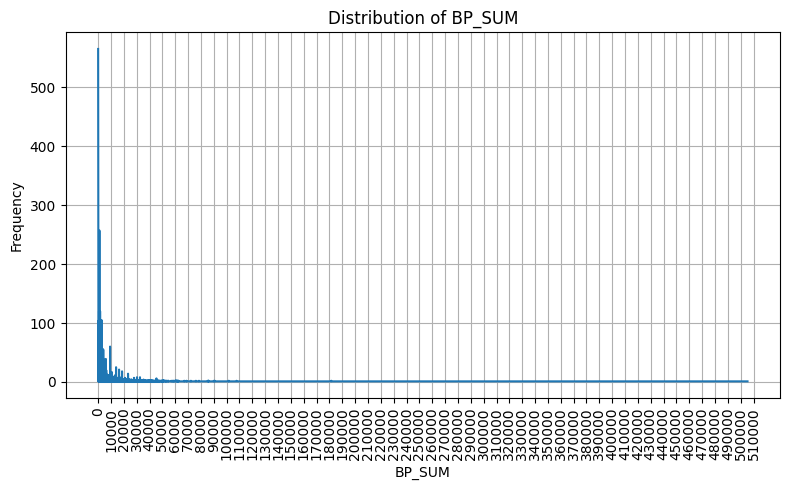

In [ ]:
age_counts = (
    df['BP_SUM']
    .value_counts()
    .sort_index()
)

xmin = int(age_counts.index.min())
xmax = int(age_counts.index.max())

plt.figure(figsize=(8, 5))
plt.plot(age_counts.index, age_counts.values)
plt.xticks(range(xmin - xmin % 10000, xmax + 10000, 10000), rotation='vertical')
plt.xlabel('BP_SUM')
plt.ylabel('Frequency')
plt.title('Distribution of BP_SUM')
plt.grid(True)
plt.tight_layout()

plt.show()

### 'SUM_YR_1' Analyis

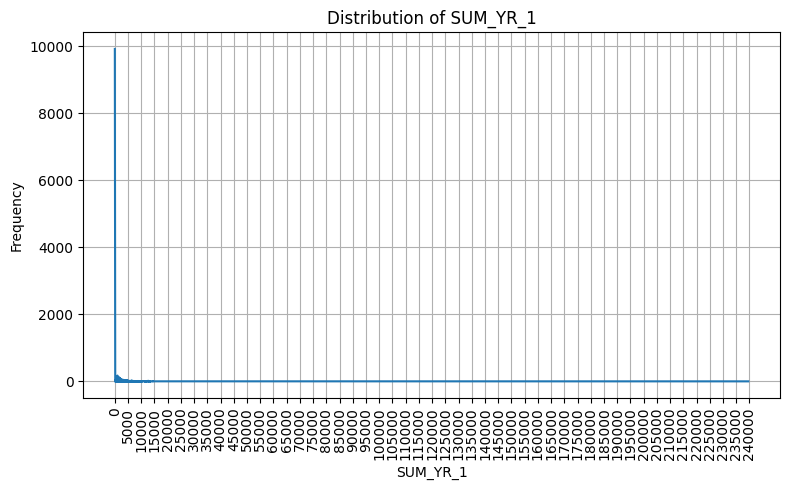

In [ ]:
age_counts = (
    df['SUM_YR_1']
    .value_counts()
    .sort_index()
)

xmin = int(age_counts.index.min())
xmax = int(age_counts.index.max())

plt.figure(figsize=(8, 5))
plt.plot(age_counts.index, age_counts.values)
plt.xticks(range(xmin - xmin % 5000, xmax + 5000, 5000), rotation='vertical')
plt.xlabel('SUM_YR_1')
plt.ylabel('Frequency')
plt.title('Distribution of SUM_YR_1')
plt.grid(True)
plt.tight_layout()

plt.show()

### 'SUM_YR_2' Analysis

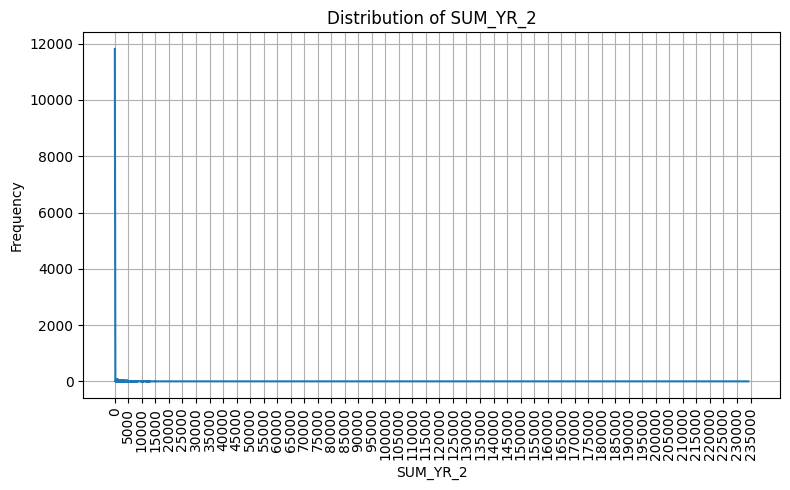

In [ ]:
age_counts = (
    df['SUM_YR_2']
    .value_counts()
    .sort_index()
)

xmin = int(age_counts.index.min())
xmax = int(age_counts.index.max())

plt.figure(figsize=(8, 5))
plt.plot(age_counts.index, age_counts.values)
plt.xticks(range(xmin - xmin % 5000, xmax + 5000, 5000), rotation='vertical')
plt.xlabel('SUM_YR_2')
plt.ylabel('Frequency')
plt.title('Distribution of SUM_YR_2')
plt.grid(True)
plt.tight_layout()

plt.show()

### 'SEG_KM_SUM' Analysis

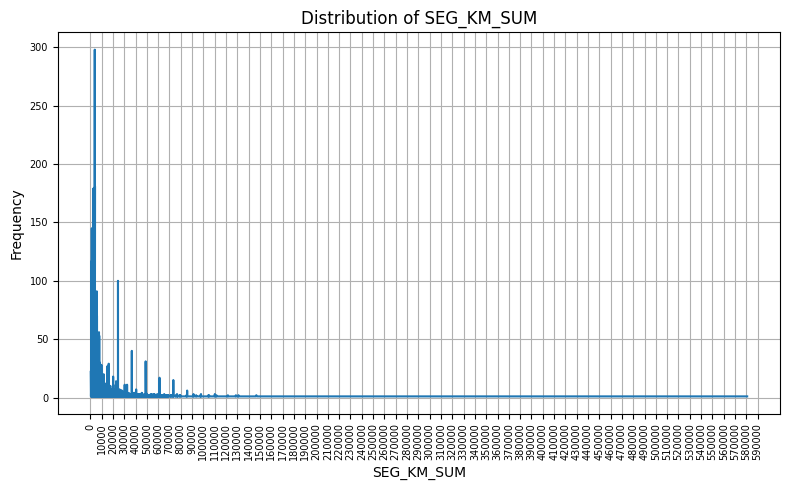

In [ ]:
age_counts = (
    df['SEG_KM_SUM']
    .value_counts()
    .sort_index()
)

xmin = int(age_counts.index.min())
xmax = int(age_counts.index.max())

plt.figure(figsize=(8, 5))
plt.plot(age_counts.index, age_counts.values)
plt.xticks(range(xmin - xmin % 10000, xmax + 10000, 10000), rotation='vertical')
plt.tick_params(axis='both', labelsize=7)
plt.xlabel('SEG_KM_SUM')
plt.ylabel('Frequency')
plt.title('Distribution of SEG_KM_SUM')
plt.grid(True)
plt.tight_layout()

plt.show()

### 'LAST_FLIGHT_DATE' Analysis

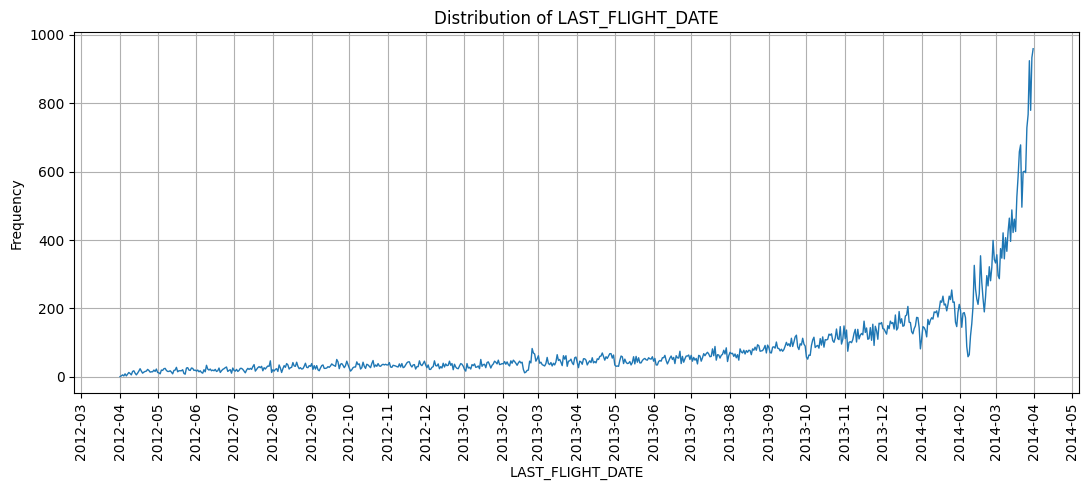

In [ ]:
daily_counts = df.groupby('LAST_FLIGHT_DATE').size()

# plot
plt.figure(figsize=(11, 5))
plt.plot(daily_counts.index, daily_counts.values, linewidth=1.0)

# reduce x-axis tick frequency
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())      # one tick per month
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation='vertical')
plt.xlabel('LAST_FLIGHT_DATE')
plt.ylabel('Frequency')
plt.title('Distribution of LAST_FLIGHT_DATE')
plt.grid(True)
plt.tight_layout()
plt.show()

### 'LAST_TO_END' Analysis

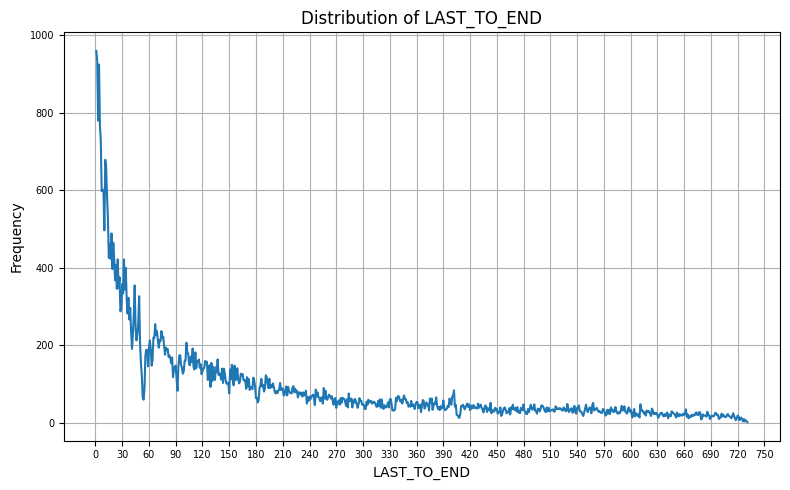

In [ ]:
age_counts = (
    df['LAST_TO_END']
    .value_counts()
    .sort_index()
)
xmin = int(age_counts.index.min())
xmax = int(age_counts.index.max())

plt.figure(figsize=(8, 5))
plt.plot(age_counts.index, age_counts.values)

plt.tick_params(axis='both', labelsize=7)
plt.xticks(range(xmin - xmin % 30, xmax + 30, 30))
plt.xlabel('LAST_TO_END')
plt.ylabel('Frequency')
plt.title('Distribution of LAST_TO_END')
plt.grid(True)
plt.tight_layout()
plt.show()

### 'AVG_INTERVAL' Analysis

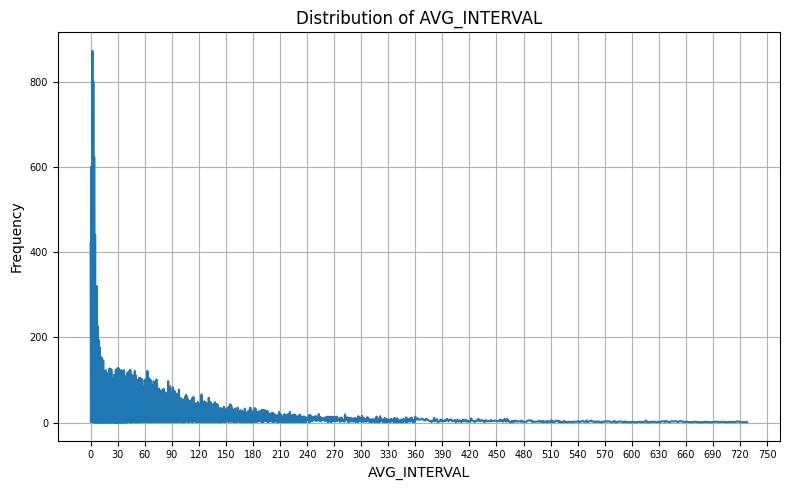

In [ ]:
age_counts = (
    df['AVG_INTERVAL']
    .value_counts()
    .sort_index()
)
xmin = int(age_counts.index.min())
xmax = int(age_counts.index.max())

plt.figure(figsize=(8, 5))
plt.plot(age_counts.index, age_counts.values)

plt.tick_params(axis='both', labelsize=7)
plt.xticks(range(xmin - xmin % 30, xmax + 30, 30))
plt.xlabel('AVG_INTERVAL')
plt.ylabel('Frequency')
plt.title('Distribution of AVG_INTERVAL')
plt.grid(True)
plt.tight_layout()
plt.show()

### 'MAX_INTERVAL' Analysis

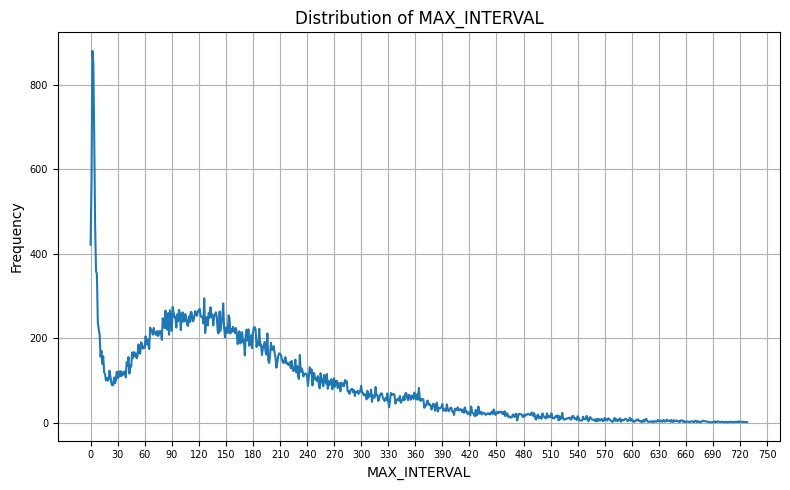

In [ ]:
age_counts = (
    df['MAX_INTERVAL']
    .value_counts()
    .sort_index()
)
xmin = int(age_counts.index.min())
xmax = int(age_counts.index.max())

plt.figure(figsize=(8, 5))
plt.plot(age_counts.index, age_counts.values)

plt.tick_params(axis='both', labelsize=7)
plt.xticks(range(xmin - xmin % 30, xmax + 30, 30))
plt.xlabel('MAX_INTERVAL')
plt.ylabel('Frequency')
plt.title('Distribution of MAX_INTERVAL')
plt.grid(True)
plt.tight_layout()
plt.show()

### 'EXCHANGE_COUNT' Analysis

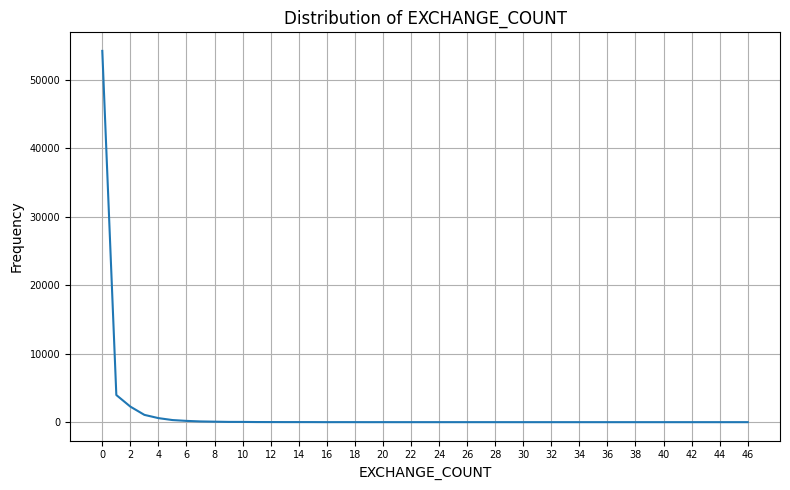

In [ ]:
age_counts = (
    df['EXCHANGE_COUNT']
    .value_counts()
    .sort_index()
)
xmin = int(age_counts.index.min())
xmax = int(age_counts.index.max())

plt.figure(figsize=(8, 5))
plt.plot(age_counts.index, age_counts.values)

plt.tick_params(axis='both', labelsize=7)
plt.xticks(range(xmin - xmin % 2, xmax + 2, 2))
plt.xlabel('EXCHANGE_COUNT')
plt.ylabel('Frequency')
plt.title('Distribution of EXCHANGE_COUNT')
plt.grid(True)
plt.tight_layout()
plt.show()

### 'avg_discount' Analysis

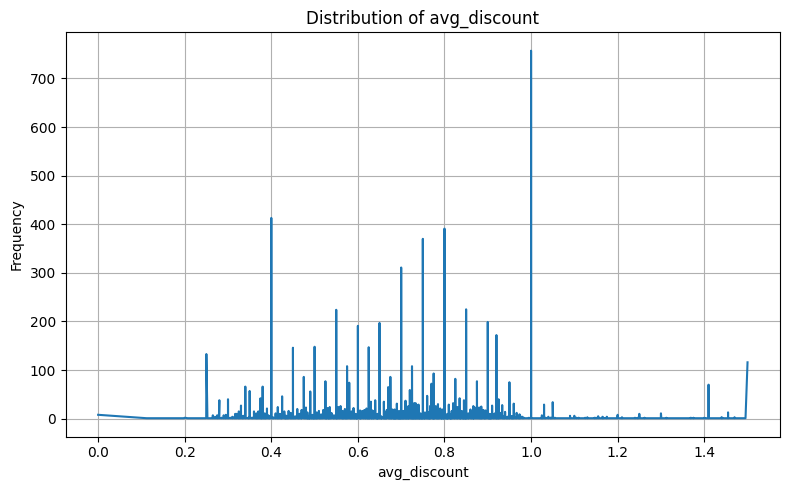

In [ ]:
age_counts = (
    df['avg_discount']
    .value_counts()
    .sort_index()
)
xmin = int(age_counts.index.min())
xmax = int(age_counts.index.max())

plt.figure(figsize=(8, 5))
plt.plot(age_counts.index, age_counts.values)

# plt.tick_params(axis='both', labelsize=7)
# plt.xticks(range(xmin - xmin % 2, xmax + 2, 2))
plt.xlabel('avg_discount')
plt.ylabel('Frequency')
plt.title('Distribution of avg_discount')
plt.grid(True)
plt.tight_layout()
plt.show()

### 'Points_Sum' Analysis

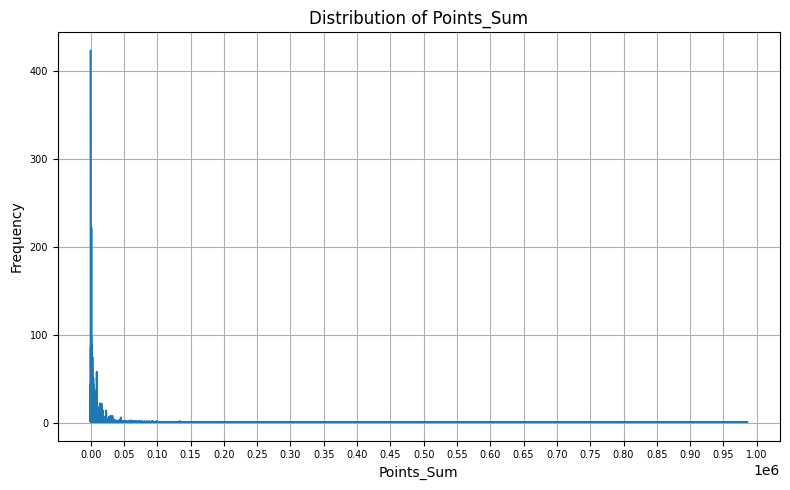

In [ ]:
age_counts = (
    df['Points_Sum']
    .value_counts()
    .sort_index()
)
xmin = int(age_counts.index.min())
xmax = int(age_counts.index.max())

plt.figure(figsize=(8, 5))
plt.plot(age_counts.index, age_counts.values)

plt.tick_params(axis='both', labelsize=7)
plt.xticks(range(xmin - xmin % 50000, xmax + 50000, 50000))
plt.xlabel('Points_Sum')
plt.ylabel('Frequency')
plt.title('Distribution of Points_Sum')
plt.grid(True)
plt.tight_layout()
plt.show()

### 'Point_NotFlight' Analysis

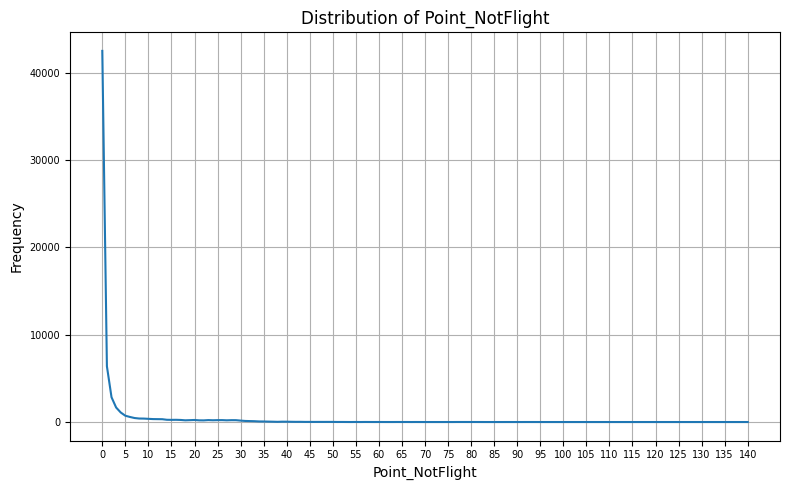

In [ ]:
age_counts = (
    df['Point_NotFlight']
    .value_counts()
    .sort_index()
)
xmin = int(age_counts.index.min())
xmax = int(age_counts.index.max())

plt.figure(figsize=(8, 5))
plt.plot(age_counts.index, age_counts.values)

plt.tick_params(axis='both', labelsize=7)
plt.xticks(range(xmin - xmin % 5, xmax + 5, 5))
plt.xlabel('Point_NotFlight')
plt.ylabel('Frequency')
plt.title('Distribution of Point_NotFlight')
plt.grid(True)
plt.tight_layout()
plt.show()

## Multivariate Analysis

### Numerical Data Analysis

In [ ]:
num_cols = ['FFP_DATE', 'FIRST_FLIGHT_DATE', 'GENDER', 'FFP_TIER','AGE', 'FLIGHT_COUNT', 'BP_SUM', 'SUM_YR_1', 'SUM_YR_2', 'SEG_KM_SUM', 'LAST_FLIGHT_DATE',
            'LAST_TO_END', 'AVG_INTERVAL', 'MAX_INTERVAL', 'EXCHANGE_COUNT', 'avg_discount', 'Points_Sum', 'Point_NotFlight']

<Axes: >

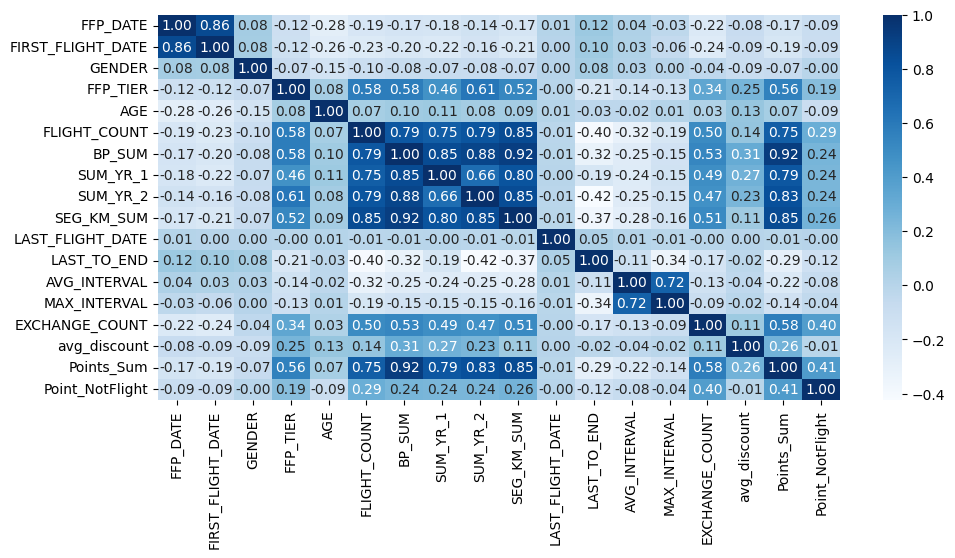

In [ ]:
fig, (ax1) = plt.subplots(1, 1, figsize=(11, 5))
sns.heatmap(df[num_cols].corr(), cmap='Blues', annot=True, fmt='.2f')

### Categorical Data Analysis

In [ ]:
cat_cols = ['WORK_CITY', 'WORK_PROVINCE', 'WORK_COUNTRY']

In [ ]:
# Cramér’s V function
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(table)
    n = table.values.sum()
    r, k = table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# Initialize association matrix
assoc_matrix = pd.DataFrame(
    np.zeros((len(cat_cols), len(cat_cols))),
    index=cat_cols,
    columns=cat_cols
)

# Compute pairwise Cramér’s V
for a, b in itertools.combinations(cat_cols, 2):
    v = cramers_v(df[a], df[b])
    assoc_matrix.loc[a, b] = v
    assoc_matrix.loc[b, a] = v

# Diagonal = 1 (self-association)
np.fill_diagonal(assoc_matrix.values, 1.0)

assoc_matrix

,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY
WORK_CITY,1.000000,0.855608,0.883701
WORK_PROVINCE,0.855608,1.000000,0.837146
WORK_COUNTRY,0.883701,0.837146,1.000000


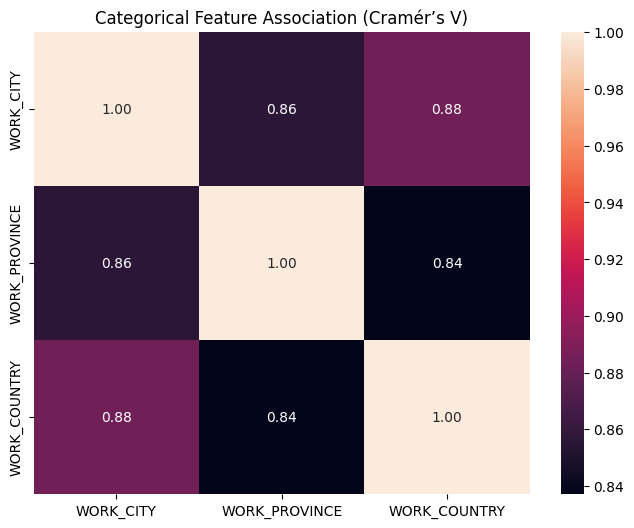

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    assoc_matrix,
    annot=True,
    fmt=".2f"
)
plt.title("Categorical Feature Association (Cramér’s V)")
plt.show()

## Conclusion

### Features Engineered

*   FLIGHT_FREQ:
    *   Fitur ini dibuat untuk menghitung apakah seorang pelanggan sering terbang atau tidak.<br>Fitur ini dibuat dari komponen FLIGHT_COUNT/(LAST_FLIGHT_DATE - FIRST_FLIGHT_DATE)
*   AVG_SEG_KM:
    *   Fitur ini dibuat untuk menghitung apakah seorang pelanggan termasuk pelanggan yang meminati penerbangan jarak pendek atau jarak jauh.<br>Fitur ini dibuat dari komponen SEG_KM_SUM/FLIGHT_COUNT
*   LAST_TO_END:
    *   Fitur ini dipakai untuk menghitung seberapa terkini seorang pelanggan melakukan transaksi.
*   SPEND_PER_FLIGHT:
    *   Fitur ini dibuat untuk menghitung apakah seorang pelanggan lebih meminati penerbangan yang premium atau ekonomis.<br>Fitur ini dibuat dari komponen (SUM_YR_1 + SUM_YR_2) / FLIGHT_COUNT
*   avg_discount:
    *   Fitur ini dipakai untuk menghitung apakah seorang pelanggan mementingkan potongan harga saat melakukan pembelian tiket penerbangan.

### Features Used

*   FFP_DATE:
    *   Kolom tidak dipakai karena nilai korelasi yang tinggi dengan FIRST_FLIGHT_DATE, sedangkan kolom FIRST_FLIGHT_DATE nanti akan dipakai untuk *Feature Engineering/Extraction*.
*   FIRST_FLIGHT_DATE:
    *   Kolom akan dipakai untuk pembuatan data fitur baru dimana di kalkulasi frekuensi penerbangan selama masa *tenure* pelanggan.
*   GENDER:
    *   Fitur ini tidak mempunyai korelasi yang bermakna terhadap fitur lain nya, maka tidak akan dipakai.
*   FFP_TIER:
    *   90%+ dari baris memiliki nilai FFP_TIER 4, dikarenakan ada nya *class imbalance* yang ekstrim, maka di putuskan untuk tidak memakai fitur ini.
*   WORK_CITY:
    *   Dikarenakan nilai di kolom ini yang sangat tidak *standardized*, dan distribusi yang tergolong miring, maka diputuskan untuk tidak memakai fitur ini.
*   WORK_PROVINCE:
    *   Dikarenakan nilai di kolom ini yang sangat tidak *standardized*, dan distribusi yang tergolong miring, maka diputuskan untuk tidak memakai fitur ini.
*   WORK_COUNTRY:
    *   Meskipun nilai di kolom ini sudah *standardized*, namun distribusi terlihat *positively skewed* secara ekstrim dimana ada 91.7% baris yang memiliki nilai yang sama. Dikarenakan *class imbalance* yang ekstrim, maka diputuskan untuk tidak memakai kolom ini.
*   AGE:
    *   
*   LOAD_TIME:
    *   Nilai di kolom tidak ada variasi sama sekali, maka kolom ini tidak akan berguna untuk *clustering*.
*   FLIGHT_COUNT:
    *   Kolom akan dipakai untuk pembuatan data fitur baru dimana di kalkulasi frekuensi penerbangan selama masa *tenure* pelanggan.
    *   Kolom ini akan dipakai untuk pembuatan data fitur baru dimana dilakukan klasifikasi apakah pelanggan merupakan langganan penerbangan jarak dekat atau jarak jauh.
*   BP_SUM:
    *   
*   SUM_YR_1:
    *   
*   SUM_YR_2:
    *   
*   SEG_KM_SUM:
    *   Kolom ini akan dipakai untuk pembuatan data fitur baru dimana dilakukan klasifikasi apakah pelanggan merupakan langganan penerbangan jarak dekat atau jarak jauh.
*   LAST_FLIGHT_DATE:
    *   
*   LAST_TO_END:
    *   List item
*   AVG_INTERVAL:
    *   List item
*   MAX_INTERVAL:
    *   List item
*   EXCHANGE_COUNT:
    *   List item
*   LAST_FLIGHT_DATE:
    *   List item
*   LAST_TO_END:
    *   List item

# Data Cleaning

Dikarenakan data fitur yang dipakai sudah ditentukan di bagian *Conclusion* EDA, maka bisa di putuskan bahwa pembersihan data hanya dilakukan untuk kolom data yang akan dipakai saja.

## GENDER Cleaning

In [29]:
# Dikarenakan hanya ada 3 baris dimana GENDER nya nilai nya null, maka di putuskan untuk mengisi baris tersebut dengan Male.
df['GENDER'] = df['GENDER'].fillna('Male')

## AGE Cleaning

In [30]:
df['AGE'] = df['AGE'].fillna(df['AGE'].median())

## FIRST_FLIGHT_DATE Cleaning

In [31]:
# Menghapus nilai dimana tahun di kolom ini adalah 1905
df = df[df['FIRST_FLIGHT_DATE'].dt.year != 1905]

## SUM_YR_1 Cleaning

Dikarenakan distribusi kolom ini tidak normal, maka diputuskan untuk mengisi nilai NaN/null dengan median.

In [32]:
df['SUM_YR_1'] = df['SUM_YR_1'].fillna(df['SUM_YR_1'].median())

## SUM_YR_2 Cleaning

Dikarenakan distribusi kolom ini tidak normal, maka diputuskan untuk mengisi nilai NaN/null dengan median.

In [33]:
df['SUM_YR_2'] = df['SUM_YR_2'].fillna(df['SUM_YR_2'].median())

## LAST_FLIGHT_DATE Cleaning

Dikarenakan nilai LAST_TO_END ditentukan oleh nilai LAST_FLIGHT_DATE dan sebalik nya, dan juga LAST_TO_END tidak memiliki nilai null, maka LAST_TO_END bisa digunakan untuk mengisi kolom LAST_FLIGHT_DATE

In [34]:
reference_date = pd.Timestamp("2014-04-01")
mask = df['LAST_FLIGHT_DATE'].isna()

df.loc[mask, 'LAST_FLIGHT_DATE'] = (
    reference_date -
    pd.to_timedelta(df.loc[mask, 'LAST_TO_END'], unit='D')
)

# Feature Engineering

## FLIGHT_FREQ Creation

In [47]:
# compute tenure in years
tenure_days = (df['LAST_FLIGHT_DATE'] - df['FIRST_FLIGHT_DATE']).dt.days
tenure_days = tenure_days.clip(lower=1)

# print(tenure_years)

# create feature
df['FLIGHT_FREQ'] = df['FLIGHT_COUNT'] / tenure_days

In [48]:
# df['FLIGHT_FREQ'].isna().sum()
# print(type(tenure_years))
tenure_days[tenure_days == 0]

,0


## AVG_SEG_KM Creation

In [49]:
df['AVG_SEG_KM'] = df['SEG_KM_SUM'] / df['FLIGHT_COUNT'].replace(0, np.nan)

## SPEND_PER_FLIGHT Creation

In [50]:
df['SPEND_PER_FLIGHT'] = (
    (df['SUM_YR_1'] + df['SUM_YR_2']) /
    df['FLIGHT_COUNT'].replace(0, np.nan)
)

# Feature Transformation

## Feature Transformation

In [51]:
df['FLIGHT_FREQ_log'] = np.log1p(df[['FLIGHT_FREQ']])
df['AVG_SEG_KM_log'] = np.log1p(df[['AVG_SEG_KM']])
df['LAST_TO_END_log'] = np.log1p(df[['LAST_TO_END']])
df['SPEND_PER_FLIGHT_log'] = np.log1p(df[['SPEND_PER_FLIGHT']])
df['avg_discount_log'] = np.log1p(df[['avg_discount']])

df['FLIGHT_COUNT_log'] = np.log1p(df[['FLIGHT_COUNT']])
df['BP_SUM_log'] = np.log1p(df[['BP_SUM']])
df['SUM_YR_1_log'] = np.log1p(df[['SUM_YR_1']])
df['SUM_YR_2_log'] = np.log1p(df[['SUM_YR_2']])
df['SEG_KM_SUM_log'] = np.log1p(df[['SEG_KM_SUM']])
df['AVG_INTERVAL_log'] = np.log1p(df[['AVG_INTERVAL']])
df['MAX_INTERVAL_log'] = np.log1p(df[['MAX_INTERVAL']])
df['EXCHANGE_COUNT_log'] = np.log1p(df[['EXCHANGE_COUNT']])
df['Points_Sum_log'] = np.log1p(df[['Points_Sum']])
df['Point_NotFlight_log'] = np.log1p(df[['Point_NotFlight']])

## Feature Scaling

In [52]:
df['FLIGHT_FREQ_scaled'] = StandardScaler().fit_transform(df[['FLIGHT_FREQ_log']])
df['AVG_SEG_KM_scaled'] = StandardScaler().fit_transform(df[['AVG_SEG_KM_log']])
df['LAST_TO_END_scaled'] = StandardScaler().fit_transform(df[['LAST_TO_END_log']])
df['SPEND_PER_FLIGHT_scaled'] = StandardScaler().fit_transform(df[['SPEND_PER_FLIGHT_log']])
df['avg_discount_scaled'] = StandardScaler().fit_transform(df[['avg_discount_log']])

df['FLIGHT_COUNT_scaled'] = StandardScaler().fit_transform(df[['FLIGHT_COUNT_log']])
df['BP_SUM_scaled'] = StandardScaler().fit_transform(df[['BP_SUM_log']])
df['SUM_YR_1_scaled'] = StandardScaler().fit_transform(df[['SUM_YR_1_log']])
df['SUM_YR_2_scaled'] = StandardScaler().fit_transform(df[['SUM_YR_2_log']])
df['SEG_KM_SUM_scaled'] = StandardScaler().fit_transform(df[['SEG_KM_SUM_log']])
df['AVG_INTERVAL_scaled'] = StandardScaler().fit_transform(df[['AVG_INTERVAL_log']])
df['MAX_INTERVAL_scaled'] = StandardScaler().fit_transform(df[['MAX_INTERVAL_log']])
df['EXCHANGE_COUNT_scaled'] = StandardScaler().fit_transform(df[['EXCHANGE_COUNT_log']])
df['Points_Sum_scaled'] = StandardScaler().fit_transform(df[['Points_Sum_log']])
df['Point_NotFlight_scaled'] = StandardScaler().fit_transform(df[['Point_NotFlight_log']])

In [53]:
df.head()

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME,...,FLIGHT_COUNT_scaled,BP_SUM_scaled,SUM_YR_1_scaled,SUM_YR_2_scaled,SEG_KM_SUM_scaled,AVG_INTERVAL_scaled,MAX_INTERVAL_scaled,EXCHANGE_COUNT_scaled,Points_Sum_scaled,Point_NotFlight_scaled
0,54993,2006-11-02,2008-12-24,0,6,.,beijing,CN,31.0,3/31/2014,...,3.820973,3.255807,1.742163,1.676812,3.963555,-2.062980,-1.417556,8.372623,3.405245,3.445569
1,28065,2007-02-19,2007-08-03,0,6,NaN,beijing,CN,42.0,3/31/2014,...,3.337557,3.017633,1.635651,1.577232,3.294897,-1.764394,-1.461816,7.993723,3.111221,3.031683
2,55106,2007-02-01,2007-08-30,0,6,.,beijing,CN,40.0,3/31/2014,...,3.294258,2.994884,1.620693,1.572854,3.261037,-1.748976,-1.417556,7.117019,3.094365,2.796372
3,21189,2008-08-22,2008-08-23,0,5,Los Angeles,CA,US,64.0,3/31/2014,...,1.214034,2.966044,1.512075,1.491676,3.252789,-0.342950,-0.304540,5.741489,3.029698,2.050306
4,39546,2009-04-10,2009-04-15,0,6,guiyang,guizhou,CN,48.0,3/31/2014,...,3.435509,2.816590,1.533798,1.503729,3.347716,-1.827035,-0.658891,7.824139,2.960469,3.197577


## Feature Selection

In [54]:
df_select = df.copy()

In [55]:
df_select = df_select.drop(columns=['MEMBER_NO', 'LOAD_TIME', 'FLIGHT_COUNT', 'BP_SUM', 'SUM_YR_1', 'SUM_YR_2', 'SEG_KM_SUM', 'LAST_TO_END', 'AVG_INTERVAL',
                                    'MAX_INTERVAL', 'EXCHANGE_COUNT', 'avg_discount', 'Points_Sum', 'Point_NotFlight', 'FLIGHT_FREQ', 'AVG_SEG_KM',
                                    'SPEND_PER_FLIGHT', 'FLIGHT_FREQ_log', 'AVG_SEG_KM_log', 'LAST_TO_END_log', 'SPEND_PER_FLIGHT_log', 'avg_discount_log',
                                    'FLIGHT_COUNT_log', 'BP_SUM_log', 'SUM_YR_1_log', 'SUM_YR_2_log', 'SEG_KM_SUM_log', 'AVG_INTERVAL_log', 'MAX_INTERVAL_log',
                                    'EXCHANGE_COUNT_log', 'Points_Sum_log', 'Point_NotFlight_log', 'WORK_CITY', 'WORK_PROVINCE', 'WORK_COUNTRY'])

In [56]:
cols_with_nulls = df_select.columns[df_select.isna().any()]

print(cols_with_nulls.tolist())

[]


In [57]:
# df_select['FLIGHT_COUNT_scaled'] = df_select['FLIGHT_COUNT_scaled'].str.strip()
# df_select['FLIGHT_COUNT_scaled'] = df_select['FLIGHT_COUNT_scaled'].replace(
#     ['', ' ', 'NULL', 'null', 'None', 'NA', '?'],
#     pd.NA
# )
df_select[df_select['FLIGHT_FREQ_scaled'].isna()]
# df_select[df_select['FLIGHT_COUNT_scaled'].isna()]

,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,AGE,LAST_FLIGHT_DATE,FLIGHT_FREQ_scaled,AVG_SEG_KM_scaled,LAST_TO_END_scaled,SPEND_PER_FLIGHT_scaled,...,FLIGHT_COUNT_scaled,BP_SUM_scaled,SUM_YR_1_scaled,SUM_YR_2_scaled,SEG_KM_SUM_scaled,AVG_INTERVAL_scaled,MAX_INTERVAL_scaled,EXCHANGE_COUNT_scaled,Points_Sum_scaled,Point_NotFlight_scaled


## PCA

In [58]:
features = [
    'FLIGHT_FREQ_scaled',
    'AVG_SEG_KM_scaled',
    'LAST_TO_END_scaled',
    'SPEND_PER_FLIGHT_scaled',
    'avg_discount_scaled',
    'FLIGHT_COUNT_scaled',
    'BP_SUM_scaled',
    'SUM_YR_1_scaled',
    'SUM_YR_2_scaled',
    'SEG_KM_SUM_scaled',
    'AVG_INTERVAL_scaled',
    'MAX_INTERVAL_scaled',
    'EXCHANGE_COUNT_scaled',
    'Points_Sum_scaled',
    'Point_NotFlight_scaled',
    'AGE'
]

In [59]:
X = df_select[features].values

In [60]:
pca_cluster = PCA(n_components=16, random_state=42)
X_pca = pca_cluster.fit_transform(X)

pdf = pd.DataFrame(data = X_pca, columns =['pcs1', 'pcs2', 'pcs3', 'pcs4', 'pcs5', 'pcs6', 'pcs7', 'pcs8', 'pcs9', 'pcs10', 'pcs11', 'pcs12', 'pcs13', 'pcs14', 'pcs15', 'pcs16'])

# Modeling

## Elbow Method

In [61]:
inertia = []
K_range = range(2, 14)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pdf)
    inertia.append(kmeans.inertia_)

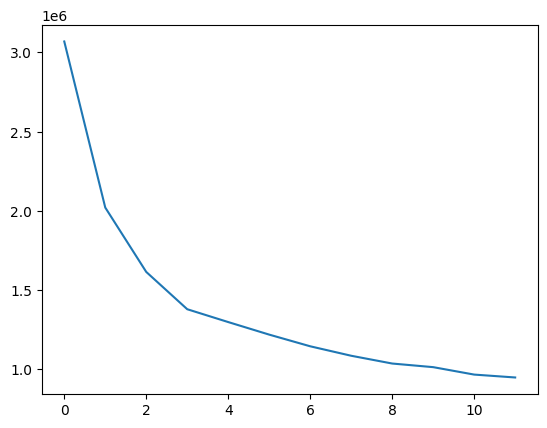

In [62]:
plt.plot(inertia)

## Clustering

In [63]:
kmeans = KMeans(n_clusters=8, init='k-means++', max_iter=300, n_init=10, random_state=42)

labels = kmeans.fit_predict(X_pca)
df_select['cluster'] = labels

In [71]:
score = silhouette_score(X, labels)
score

np.float64(0.18166368397846566)

In [64]:
pca_vis = PCA(n_components=2, random_state=42)
X_vis = pca_vis.fit_transform(X)

## Clustering Visualization

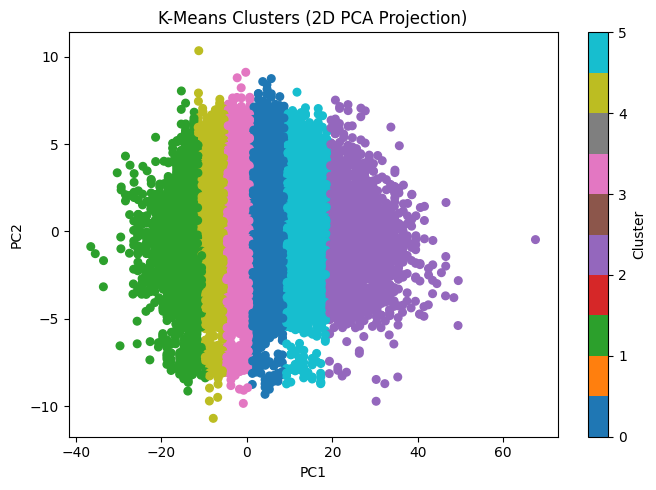

In [65]:
plt.figure(figsize=(7, 5))
plt.scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    c=labels,
    cmap='tab10',
    s=30
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters (2D PCA Projection)")
plt.colorbar(label="Cluster")
plt.tight_layout()
plt.show()

## Clustering Evaluation

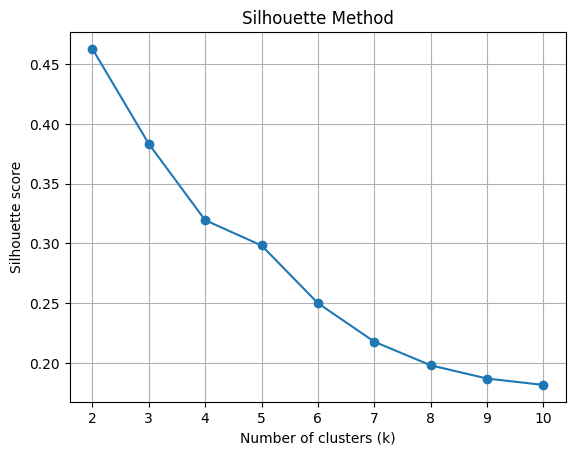

In [70]:
silhouette_scores = []

k_range = range(2, 11)
for k in k_range:
    labels = KMeans(n_clusters=k, random_state=42).fit_predict(X)
    silhouette_scores.append(silhouette_score(X, labels))

plt.figure()
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Method")
plt.grid(True)
plt.show()

In [66]:
cluster_profile = (
    df_select
    .groupby('cluster')[features]
    .mean()
    .round(2)
)

cluster_profile

,FLIGHT_FREQ_scaled,AVG_SEG_KM_scaled,LAST_TO_END_scaled,SPEND_PER_FLIGHT_scaled,avg_discount_scaled,FLIGHT_COUNT_scaled,BP_SUM_scaled,SUM_YR_1_scaled,SUM_YR_2_scaled,SEG_KM_SUM_scaled,AVG_INTERVAL_scaled,MAX_INTERVAL_scaled,EXCHANGE_COUNT_scaled,Points_Sum_scaled,Point_NotFlight_scaled,AGE
cluster,,,,,,,,,,,,,,,,
0,-0.05,-0.01,-0.09,0.04,0.09,0.13,0.12,0.07,0.09,0.11,-0.01,0.04,0.02,0.10,-0.07,47.02
1,0.20,0.03,0.21,-0.12,-0.30,-0.37,-0.40,-0.22,-0.23,-0.33,0.02,-0.14,-0.18,-0.36,0.03,28.94
2,-0.04,0.21,0.08,0.23,0.15,-0.06,0.06,0.13,-0.05,0.04,0.00,-0.03,-0.02,0.00,-0.23,67.24
3,-0.02,-0.02,-0.04,-0.01,0.00,0.05,0.05,0.01,0.03,0.04,-0.02,0.01,0.05,0.05,0.04,40.37
4,-0.02,-0.05,0.01,-0.07,-0.06,-0.01,-0.03,-0.05,-0.01,-0.03,0.02,0.03,0.03,-0.00,0.15,34.76
5,-0.04,0.04,-0.02,0.11,0.18,0.08,0.12,0.11,0.05,0.10,-0.01,0.02,0.01,0.09,-0.13,55.62


In [67]:
df['cluster'] = labels

In [68]:
df.head()

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME,...,BP_SUM_scaled,SUM_YR_1_scaled,SUM_YR_2_scaled,SEG_KM_SUM_scaled,AVG_INTERVAL_scaled,MAX_INTERVAL_scaled,EXCHANGE_COUNT_scaled,Points_Sum_scaled,Point_NotFlight_scaled,cluster
0,54993,2006-11-02,2008-12-24,0,6,.,beijing,CN,31.0,3/31/2014,...,3.255807,1.742163,1.676812,3.963555,-2.062980,-1.417556,8.372623,3.405245,3.445569,4
1,28065,2007-02-19,2007-08-03,0,6,NaN,beijing,CN,42.0,3/31/2014,...,3.017633,1.635651,1.577232,3.294897,-1.764394,-1.461816,7.993723,3.111221,3.031683,3
2,55106,2007-02-01,2007-08-30,0,6,.,beijing,CN,40.0,3/31/2014,...,2.994884,1.620693,1.572854,3.261037,-1.748976,-1.417556,7.117019,3.094365,2.796372,3
3,21189,2008-08-22,2008-08-23,0,5,Los Angeles,CA,US,64.0,3/31/2014,...,2.966044,1.512075,1.491676,3.252789,-0.342950,-0.304540,5.741489,3.029698,2.050306,2
4,39546,2009-04-10,2009-04-15,0,6,guiyang,guizhou,CN,48.0,3/31/2014,...,2.816590,1.533798,1.503729,3.347716,-1.827035,-0.658891,7.824139,2.960469,3.197577,0


## Clustering Analysis

*   Cluster 0:
    *   Pelanggan rata-rata yang tidak mempunyai sinyal negatif maupun positif.
*   Cluster 1:
    *   Pelanggan yang lebih senior dan lebih condong terbang dengan jarak yang jauh dan juga biasa nya menghabiskan uang lebih banyak per penerbangan.
*   Cluster 2:
    *   Pelanggan yang relatif sering terbang dan juga responsif terhadap diskon.
*   Cluster 3:
    *   Pelanggan yang lebih sering terbang.
*   Cluster 4:
    *   Pelanggan yang memilih untuk tidak banyak *spending*.
*   Cluster 5:
    *   Pelanggan yang condong berumur muda dan juga jarang terbang ataupun untuk melakukan *spending* lebih.


## Business Recommendation

*   Cluster 0:
    *   Tidak ada perlakukan khusus dikarenakan pelanggan di segment ini tidak responsif terhadap promosi atau diskon.
*   Cluster 1:
    *   Menawarkan *upgrade* yang condong terhadap kenyamanan seperti *upgrade* kelas penerbangan atau bangku yang lebih dekat dengan toilet.
*   Cluster 2:
    *   Menawarkan bundling ekonomis yang sudah termasuk penerbangan, bagasi, dan bangku yang lebih luas ruangan kaki nya.<br>Juga menawarkan insentif agar pelanggan tetap loyal dan sering terbang.
*   Cluster 3:
    *   Menawarkan insentif agar pelanggan tetap loyal dan sering terbang.
*   Cluster 4:
    *   Tidak ada perlakuan khusus karena pelanggan di cluster ini termasuk *low-profit*.
*   Cluster 5:
    *   Melakukan edukasi benefit saat menjadi pelanggan yang loyal. Dan juga memberi insentif saat terbang pertama kali dengan penerbangan ini.